In [1]:
# seaborn => 박스 플롯, 바이올린 플롯, 히트맵, 카운트 플롯, 페어플롯

In [2]:
# 박스플롯 / 바이올린플롯 활용 : 데이터분포와 이상치 탐지.
# A교대조 생산량이 왜 낮지? => 박스플롯으로 교대조별로 비교.
# B제품의 불량률이 들쭉날쭉하네? => 바이올린플롯으로 분포 형태 확인
# 특정 날짜에 급격한 변화가?? => 이상치로 문제 시점을 발견 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from koreanize_matplotlib import koreanize
koreanize()

In [5]:
production_df = pd.read_csv('./data/05_production.csv', parse_dates=['production_date'])

In [6]:
sensor_df = pd.read_csv('./data/08_sensor_data.csv', parse_dates=['measurement_time'] )

In [7]:
production_df['불량률'] = (production_df['defect_quantity'] / production_df['actual_quantity'] * 100).round(2)    

In [8]:
# 교대조별로 생산량을 확인

In [9]:
production_df.columns

Index(['production_id', 'equipment_id', 'product_code', 'production_date',
       'start_time', 'end_time', 'target_quantity', 'actual_quantity',
       'good_quantity', 'defect_quantity', 'cycle_time', 'work_order_no',
       'lot_no', 'operator_id', 'shift', 'created_at', 'updated_at', '불량률'],
      dtype='object')

C:\Users\hwapyeong\AppData\Local\Temp\ipykernel_19036\1026727494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= production_df , x= 'shift', y= 'actual_quantity', palette='Set2' )


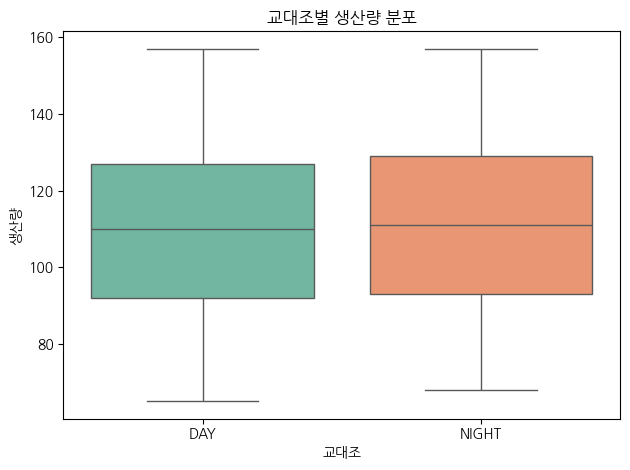

In [ ]:
# 박스 플롯 

# 집단 간 분포 비교에 좋음
# 5가지 시각화 : 최솟값, q1, 중앙값, q3, 최대값, 이상치 표시

# 시본 라이브러리는 data파라미터에 데이터프레임을 넣어준다.
# x, y 값에 컬럼이름을 적는다.

#
sns.boxplot(data= production_df , x= 'shift', y= 'actual_quantity', palette='Set2' )
plt.title('교대조별 생산량 분포')
plt.xlabel('교대조')
plt.ylabel('생산량')
plt.tight_layout()
plt.show()

In [11]:
# 제품별 교대조별 불량률

In [12]:
production_df.columns

Index(['production_id', 'equipment_id', 'product_code', 'production_date',
       'start_time', 'end_time', 'target_quantity', 'actual_quantity',
       'good_quantity', 'defect_quantity', 'cycle_time', 'work_order_no',
       'lot_no', 'operator_id', 'shift', 'created_at', 'updated_at', '불량률'],
      dtype='object')

<Axes: xlabel='product_code', ylabel='불량률'>

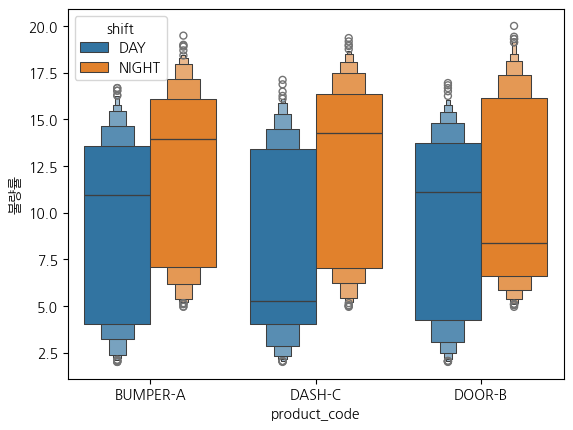

In [ ]:
# boxen plot
# 박스 플롯에서 더 심화된 버전, 꼬리 부분을 더 정교하게 보여줌, 데이터 양이 많을 수록 유리
sns.boxenplot(data=production_df, x='product_code', y='불량률', hue='shift')

In [14]:
# 바이올린 플롯 
# 박스플롯은 5가지만 보여준다 : 중앙값, q1, q3, 최소값, 최대값
# 분포의 밀도

In [15]:
# B 제품의 불량률이 평균 2%인데 왜 관리가 안되나?
# 바이올린플롯으로 확인가능
#  - 두개의 봉우리 발견할수 있다.

In [16]:
# 교대조별로 생산량 분포

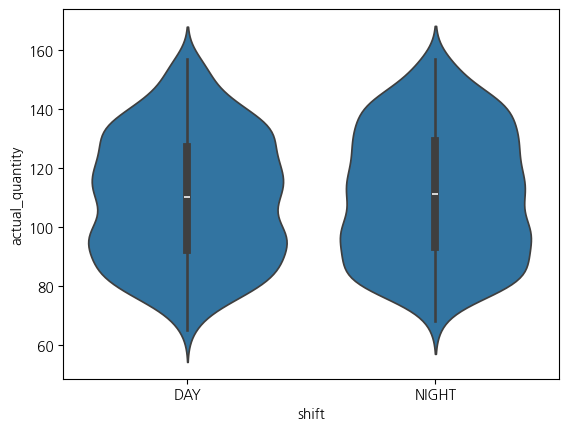

In [17]:
sns.violinplot(data= production_df, x='shift' , y='actual_quantity')
plt.show()

In [ ]:
# 히트맵 : 데이터의 밀도를 색으로 표현해서 한번에 우리눈에 보여주고 싶을때
# 상관 관계의 시각화

In [19]:
sensor_corr = sensor_df.loc[ : , 'temperature' : 'current'].corr()

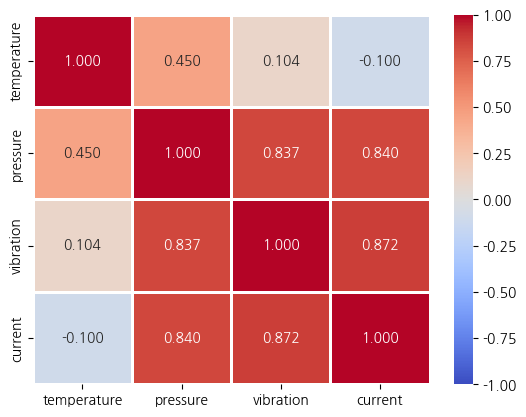

In [20]:
sns.heatmap( data= sensor_corr, cmap='coolwarm', vmin= -1, vmax= 1, linewidths=0.9,
           annot= True, fmt='.3f')
plt.show()

In [21]:
# 카운트플롯
# 컬럼에 들어있는 데이터의 갯수를 알아서 세어서, 차트로 표시해준다

In [22]:
# 설비별로 생산건수를 표시

In [ ]:
my_order = production_df['equipment_id'].value_counts().index
# 순서를 다시 정해 줘서 넣어줄 수도 있음

In [24]:
my_color = sns.color_palette()[3]

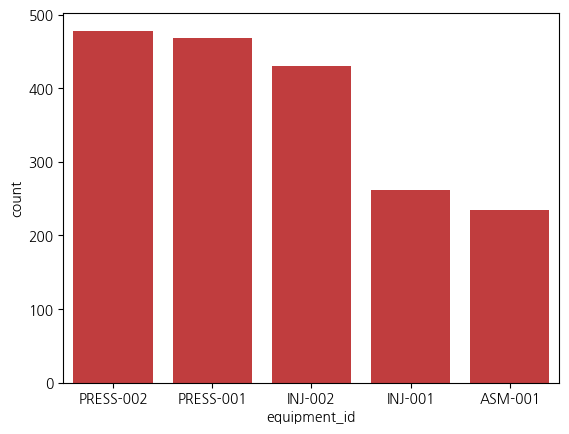

In [25]:
sns.countplot(data= production_df, x='equipment_id', order= my_order, color=my_color)
plt.show()

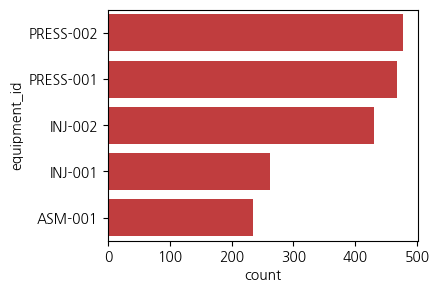

In [26]:
plt.figure(figsize=(4,3))
sns.countplot(data= production_df, y='equipment_id', order= my_order, color=my_color)
plt.show()

In [27]:
# 페어 플롯 Pair plot
# plt 의 scatter 는 두 컬럼의 관계를 보고싶을때.
# seaborn 의 pairplot은  두 컬럼의 관계를, 여러개 한번에 볼수있다.

In [ ]:
sensor_sample = sensor_df.sample( n = 500 , random_state= 12 )
# random_state는 시드

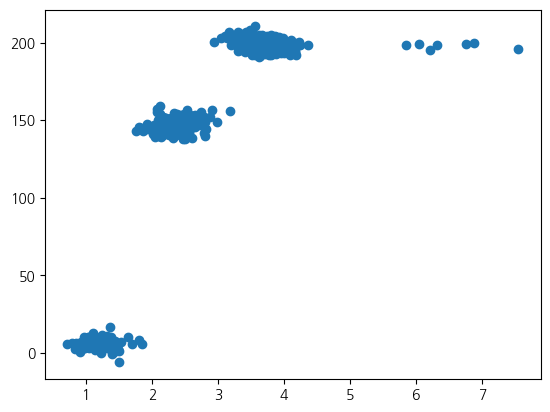

In [29]:
plt.scatter( sensor_sample['vibration']  ,  sensor_sample['pressure']  )

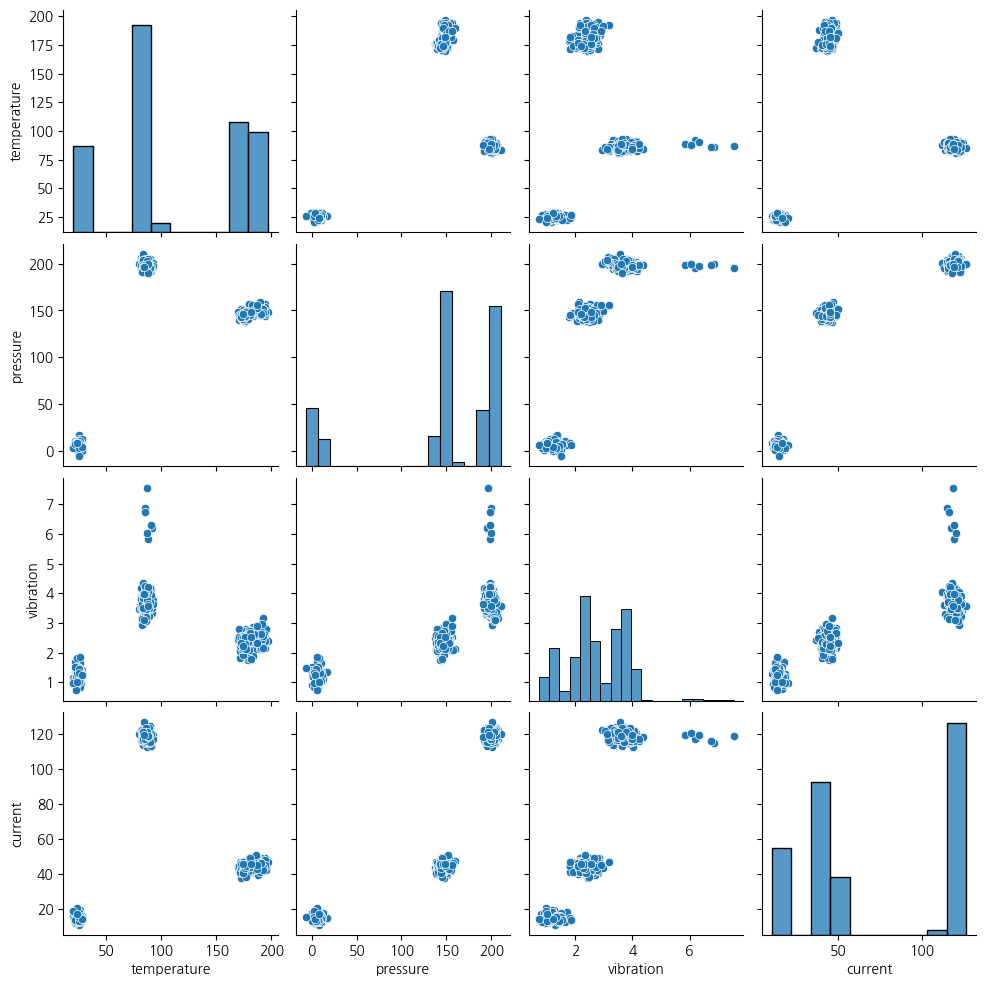

In [30]:
sns.pairplot( data= sensor_sample.loc[: , 'temperature':'current' ]  )
plt.show()

In [47]:
# 같은 변수끼리 만나면 히스토그램이 그려짐

In [48]:
# 제품별 생산량, 불량갯수, 불량률, 사이클타임 의 관계

In [32]:
production_df.columns

Index(['production_id', 'equipment_id', 'product_code', 'production_date',
       'start_time', 'end_time', 'target_quantity', 'actual_quantity',
       'good_quantity', 'defect_quantity', 'cycle_time', 'work_order_no',
       'lot_no', 'operator_id', 'shift', 'created_at', 'updated_at', '불량률'],
      dtype='object')

In [33]:
prod_df = production_df[ ['actual_quantity','defect_quantity', '불량률' ,'cycle_time', 'product_code'] ]                 

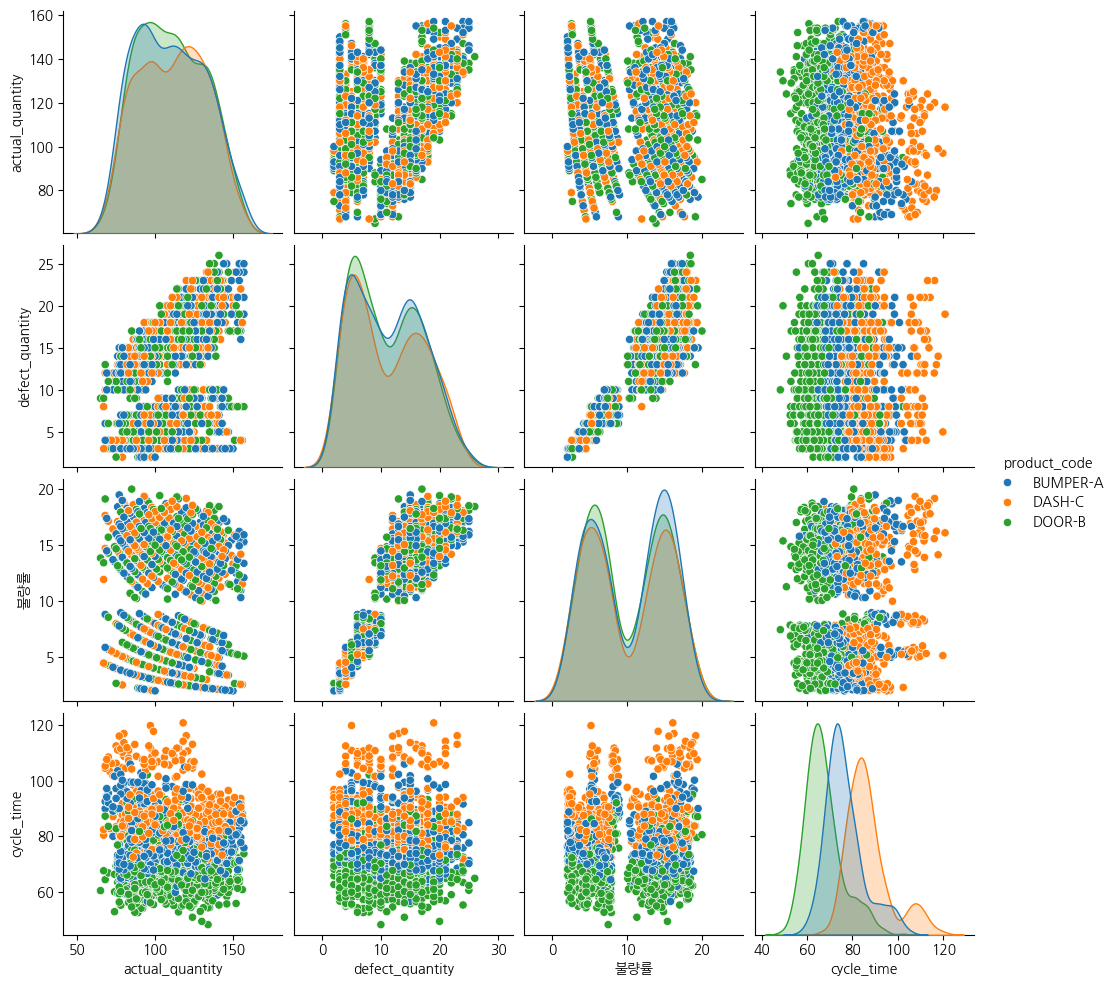

In [ ]:
sns.pairplot(data= prod_df, hue='product_code')
plt.show()
#제품별 각 컬럼의 관계도 볼 수 있다

In [35]:
# pointplot 

In [36]:
# 제품 - 교재조 별 평균 생산량

In [37]:
production_df.groupby( ['product_code','shift'  ] )['actual_quantity'].mean()

product_code  shift
BUMPER-A      DAY      109.024540
              NIGHT    110.537267
DASH-C        DAY      110.628866
              NIGHT    111.465753
DOOR-B        DAY      109.576803
              NIGHT    111.096273
Name: actual_quantity, dtype: float64

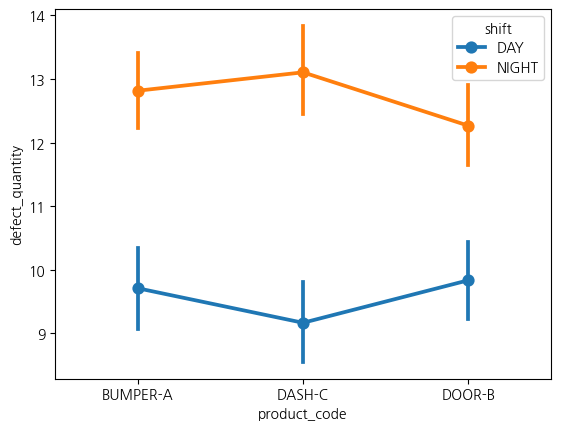

In [38]:
sns.pointplot(data= production_df, x='product_code', y='defect_quantity', hue='shift')
plt.show()

In [39]:
# 제품별 평균 불량률

In [40]:
production_df.groupby('product_code')['불량률'].mean()

product_code
BUMPER-A    10.376590
DASH-C      10.121681
DOOR-B      10.158986
Name: 불량률, dtype: float64

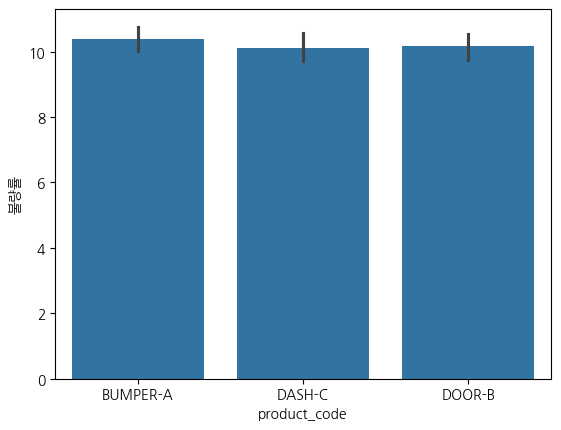

In [ ]:
sns.barplot(data = production_df , x = 'product_code', y='불량률')
plt.show()
# 선의 길이가 평균의 신뢰구간

In [42]:
# 교대조별 사이클 타임 분포

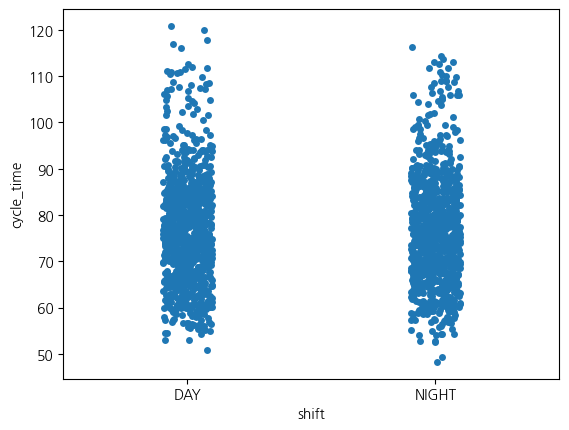

In [43]:
sns.stripplot(data= production_df , x='shift' , y='cycle_time')
plt.show()

In [44]:
# 제품별 불량률 

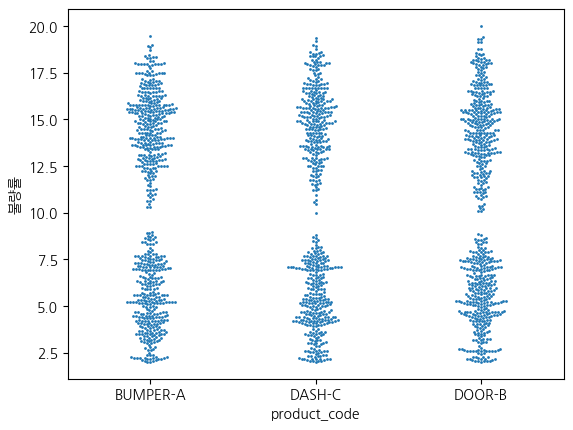

In [45]:
sns.swarmplot(data=production_df, x='product_code' , y='불량률', size=2)
plt.show()